Author(s) : Daniel R., Tarry, Laura Gómez Navarro, Elisabet Verger-Miralles

Objective: Describe xxx

Created on: October 2023

Last updated on:


In [2]:
import time

print(time.ctime(time.time()))

Fri May 31 12:26:16 2024


In [3]:
import sys
sys.path.insert(0, "../../processing/")

In [4]:
import numpy as np
import xarray as xr # version 0.20.1 necesarry, 0.16 gives error when calculating u_for
import matplotlib.pyplot as plt
import scipy.signal as signal
from scipy.signal import butter, filtfilt

import cartopy
import cartopy.crs as ccrs
import cartopy.feature       as cfeature
from cartopy.mpl.gridliner import LongitudeFormatter, LatitudeFormatter

from read_data_tools import latlon2uv_dir

In [5]:
# version_information

In [6]:
print(xr.__version__)

2023.6.0


# Parameters:

In [7]:
savedir_figs = '../proc_figures/'

# 3. Loading data

(processed here: /Users/Gomez023/src/git/FaSt-SWOT/code/data_processing/drifters/processing/SVPB_processing/drifter_SVPB038.ipynb)

In [8]:
url_drifter = "drifter_svpb038-scb_svpb038/L0/2023/dep0001_drifter-svpb038_scb-svpb038_L0_2023-04-26.nc?"

rootdir = '../../../../../'
outdir = 'data/drifters/L1_IMEDEA/'

#  Renaming as no longer using SOCIB's L0
outname = url_drifter.split('/')[-1][0:-1].replace('L0', 'L1').replace('scb', 'ime') #outname
# --> substitute L0 by L1 and scb by ime. [0:-1], because last character in string is ?
outname = outname.split('_')[1]


## Opening netcdf:

In [9]:
ds = xr.open_dataset(rootdir + outdir + outname + '.nc')

In [10]:
ds

<xarray.Dataset>
Dimensions:  (time: 831)
Coordinates:
  * time     (time) datetime64[ns] 2023-04-26T10:00:00 ... 2023-05-31
Data variables:
    LAT      (time) float64 ...
    LON      (time) float64 ...
    sst      (time) float64 ...
    slp      (time) float64 ...
    U        (time) float64 ...
    V        (time) float64 ...
Attributes: (12/69)
    title:                               Data from instrument SCB-SVPB038 on ...
    institution:                         SOCIB (Sistema de Observación y pred...
    netcdf_version:                      3.0
    Conventions:                         CF-1.6
    abstract:                            Deployment of surface drifter SCB-SV...
    summary:                             Deployment of surface drifter SCB-SV...
    ...                                  ...
    citation:                            Balearic Island Coastal and Observin...
    acknowledgement:                     National Oceanic and Atmospheric Adm...
    update_interval:                     every 7200 seconds
    DODS.strlen:                         30
    DODS.dimName:                        name_strlen
    DODS_EXTRA.Unlimited_Dimension:      time

# 4. Plotting outputs

In [11]:
map_extent=[-0.3, 7.9, 37.9, 41.5]
fsize=14


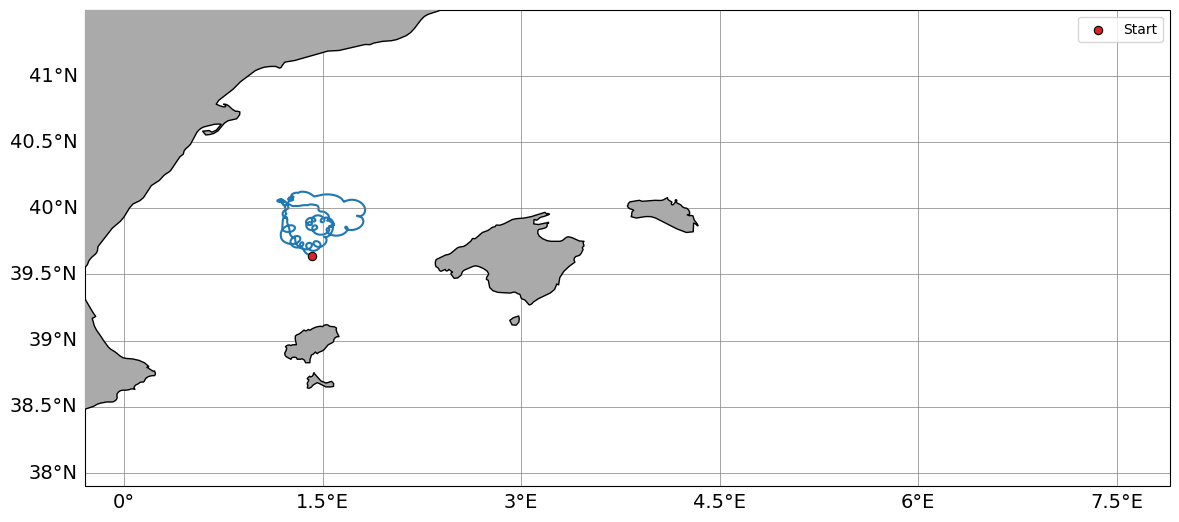

In [12]:
fig = plt.figure(figsize=(14,8))

ax1 = plt.subplot(111, projection=ccrs.PlateCarree())


#############
# Land
feature = cartopy.feature.NaturalEarthFeature(name='coastline', category='physical',
                                              scale='10m', zorder=10,
                                              edgecolor='black', facecolor='#AAAAAA')
ax1.add_feature(feature)
#############
# Grid and ticks
gl = ax1.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                  linewidth=0.5, color='gray', linestyle='-') #, alpha=0.5

gl.top_labels = False
gl.right_labels = False

gl.xlabel_style = {'size': fsize}#, 'color': 'gray'}
gl.ylabel_style = {'size': fsize}#, 'color': 'gray'}
#############

ax1.plot(ds.LON, ds.LAT, transform=ccrs.PlateCarree(), c='C0') 
ax1.scatter(ds.LON[0], ds.LAT[0], c='C3', edgecolor='k', linewidths=0.8, transform=ccrs.PlateCarree(), label='Start', zorder=50)

ax1.set_extent(map_extent, crs=ccrs.PlateCarree())
ax1.legend()
# ax1.set_title('Trajectory of ' + ds.attrs['title'].split(' ')[3].split('-')[-1], size=fsize+2) 

outname = url_drifter.split('/')[-1][0:-1].replace('L0', 'L1').replace('scb', 'ime') #outname
# --> substitute L0 by L1 and scb by ime. [0:-1], because last character in string is ?
outname = outname.split('_')[1]

# plt.savefig(savedir_figs + 'traj_proc_' + outname + '.png', dpi=300)

plt.show()

## Velocity:

In [13]:
thresa = .1
map_extent_zoom = [ds.LON.min().values - thresa, ds.LON.max().values + thresa, ds.LAT.min().values - thresa, ds.LAT.max().values + thresa]

In [14]:
abs_vel = (ds.U**2 + ds.V**2)**0.5

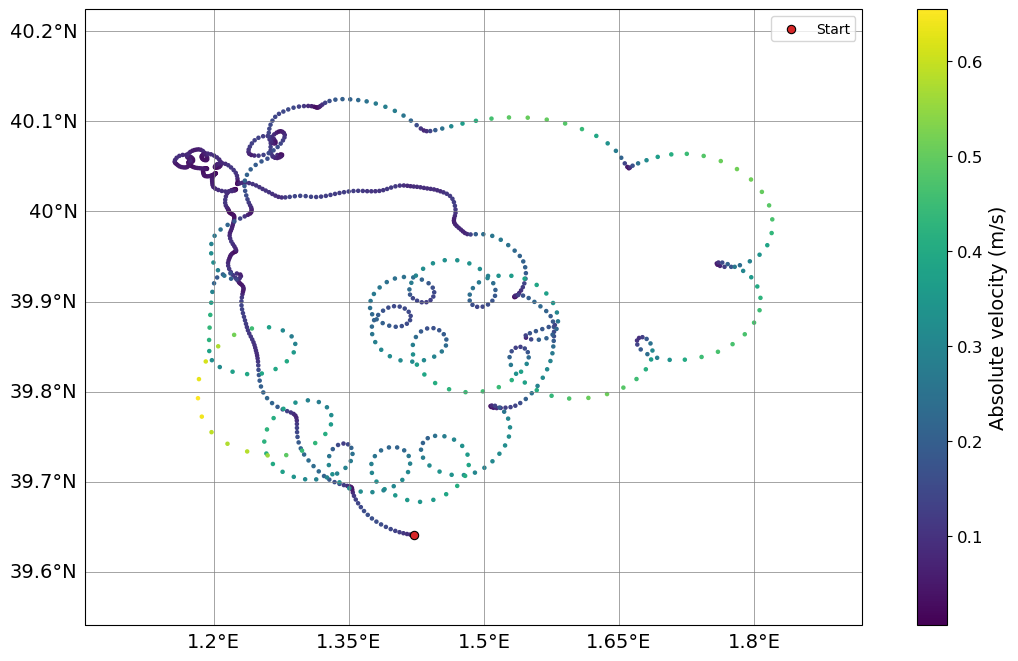

In [15]:
fig = plt.figure(figsize=(14,8))

ax1 = plt.subplot(111, projection=ccrs.PlateCarree())


#############
# Land
feature = cartopy.feature.NaturalEarthFeature(name='coastline', category='physical',
                                              scale='10m', zorder=10,
                                              edgecolor='black', facecolor='#AAAAAA')
ax1.add_feature(feature)
#############
# Grid and ticks
gl = ax1.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                  linewidth=0.5, color='gray', linestyle='-') #, alpha=0.5

gl.top_labels = False
gl.right_labels = False

gl.xlabel_style = {'size': fsize}#, 'color': 'gray'}
gl.ylabel_style = {'size': fsize}#, 'color': 'gray'}
#############

cc = ax1.scatter(ds.LON, ds.LAT, s=5, c=abs_vel, transform=ccrs.PlateCarree())
ax1.scatter(ds.LON[0], ds.LAT[0], c='C3', edgecolor='k', linewidths=0.8, transform=ccrs.PlateCarree()
            , label='Start')
cbar = plt.colorbar(cc)
cbar_label = r'Absolute velocity (m/s)'
cbar.ax.tick_params(labelsize=fsize-2)
cbar.ax.set_ylabel(cbar_label, fontsize=fsize)

ax1.set_extent(map_extent_zoom, crs=ccrs.PlateCarree())
ax1.legend()
# ax1.set_title(ds05.attrs['title'].split(' ')[3].split('-')[-1], size=fsize+2) 

outname = url_drifter.split('/')[-1][0:-1].replace('L0', 'L1').replace('scb', 'ime') #outname
# --> substitute L0 by L1 and scb by ime. [0:-1], because last character in string is ?
outname = outname.split('_')[1]

plt.savefig(savedir_figs + 'traj_proc_vels_' + outname + '.png', dpi=300)

plt.show()

# Filtering inertial osc.:

In [16]:
def butter_highpass_filter(data, cutoff, fs, order=5):
    """
    Aplica un filtro Butterworth de paso alto.
   
        Args:
        - data: Array de datos a filtrar.
        - cutoff: Frecuencia de corte del filtro.
        - fs: Frecuencia de muestreo de los datos.
        - order: Orden del filtro.
    
        Returns:
        - y: Datos filtrados.
    
    """
    nyq = 0.5 * fs
    normal_cutoff = cutoff / nyq
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    y = filtfilt(b, a, data)
    return y

In [17]:
# # Rename variables (for coherence with the other drifters)
# ds_b = ds.rename({'longitude': 'LON', 'latitude': 'LAT'})

# ds00 = ds_b.to_dataframe().set_index(['time']).to_xarray()

# --> above step necessary???

In [18]:
cuttof_frequency = 1/36 # 31 hores
fs = 1 # mostreig cada hora

In [19]:
ds.time[0:5]

<xarray.DataArray 'time' (time: 5)>
array(['2023-04-26T10:00:00.000000000', '2023-04-26T11:00:00.000000000',
       '2023-04-26T12:00:00.000000000', '2023-04-26T13:00:00.000000000',
       '2023-04-26T14:00:00.000000000'], dtype='datetime64[ns]')
Coordinates:
  * time     (time) datetime64[ns] 2023-04-26T10:00:00 ... 2023-04-26T14:00:00

# --> every 1 hour

In [20]:
ds

<xarray.Dataset>
Dimensions:  (time: 831)
Coordinates:
  * time     (time) datetime64[ns] 2023-04-26T10:00:00 ... 2023-05-31
Data variables:
    LAT      (time) float64 39.64 39.64 39.64 39.64 ... 39.87 39.87 39.87 39.88
    LON      (time) float64 1.422 1.421 1.418 1.415 ... 1.565 1.572 1.579 1.584
    sst      (time) float64 ...
    slp      (time) float64 ...
    U        (time) float64 nan -0.06372 -0.08372 -0.09435 ... 0.1631 0.1343 nan
    V        (time) float64 nan 0.01089 0.01913 0.02703 ... 0.06857 0.05643 nan
Attributes: (12/69)
    title:                               Data from instrument SCB-SVPB038 on ...
    institution:                         SOCIB (Sistema de Observación y pred...
    netcdf_version:                      3.0
    Conventions:                         CF-1.6
    abstract:                            Deployment of surface drifter SCB-SV...
    summary:                             Deployment of surface drifter SCB-SV...
    ...                                  ...
    citation:                            Balearic Island Coastal and Observin...
    acknowledgement:                     National Oceanic and Atmospheric Adm...
    update_interval:                     every 7200 seconds
    DODS.strlen:                         30
    DODS.dimName:                        name_strlen
    DODS_EXTRA.Unlimited_Dimension:      time

In [21]:
lon_filtered = butter_highpass_filter(ds.LON, cuttof_frequency, fs)
lat_filtered = butter_highpass_filter(ds.LAT, cuttof_frequency, fs)

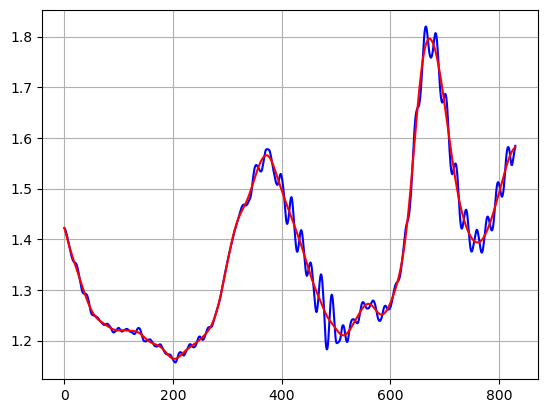

In [22]:
plt.figure()
plt.plot(ds.LON, c='b')
plt.plot(lon_filtered, c='r')
plt.grid()
plt.show()

# --> looks good!

## New dataset:

In [23]:
ds_f = ds.copy(deep=True)


In [24]:
ds_f['LON'][:] = lon_filtered
ds_f['LAT'][:] = lat_filtered

# Replotting in space:

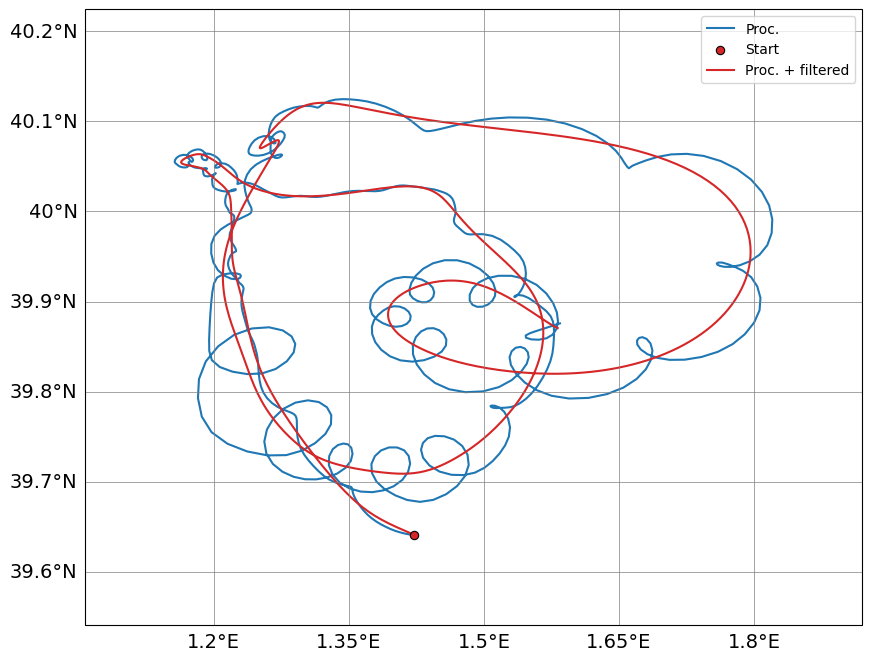

In [25]:
fig = plt.figure(figsize=(14,8))

ax1 = plt.subplot(111, projection=ccrs.PlateCarree())


#############
# Land
feature = cartopy.feature.NaturalEarthFeature(name='coastline', category='physical',
                                              scale='10m', zorder=10,
                                              edgecolor='black', facecolor='#AAAAAA')
ax1.add_feature(feature)
#############
# Grid and ticks
gl = ax1.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                  linewidth=0.5, color='gray', linestyle='-') #, alpha=0.5

gl.top_labels = False
gl.right_labels = False

gl.xlabel_style = {'size': fsize}#, 'color': 'gray'}
gl.ylabel_style = {'size': fsize}#, 'color': 'gray'}
#############

ax1.plot(ds.LON, ds.LAT, transform=ccrs.PlateCarree(), c='C0', label='Proc.') 
ax1.scatter(ds.LON[0], ds.LAT[0], c='C3', edgecolor='k', linewidths=0.8, transform=ccrs.PlateCarree(), label='Start', zorder=50)
ax1.plot(ds_f.LON, ds_f.LAT, transform=ccrs.PlateCarree(), c='C3', label='Proc. + filtered') 

ax1.set_extent(map_extent_zoom, crs=ccrs.PlateCarree())
ax1.legend()
# ax1.set_title('Trajectory of ' + ds.attrs['title'].split(' ')[3].split('-')[-1], size=fsize+2) 

# plt.savefig(savedir_figs + 'traj_proc_' + outname + '.png', dpi=300)

plt.show()

# --> super!

# Recalculating U and V:

In [26]:
temp_res = 3600. # 1 hour in seconds (double-check this value still ok here)


In [27]:
speed, ufor, vfor = latlon2uv_dir(ds_f.LAT, ds_f.LON, temp_res, 'forward')
_, uback, vback = latlon2uv_dir(ds_f.LAT, ds_f.LON, temp_res, 'back')

In [28]:
# Calculate central value
u = (ufor + uback) / 2
v = (vfor + vback) / 2

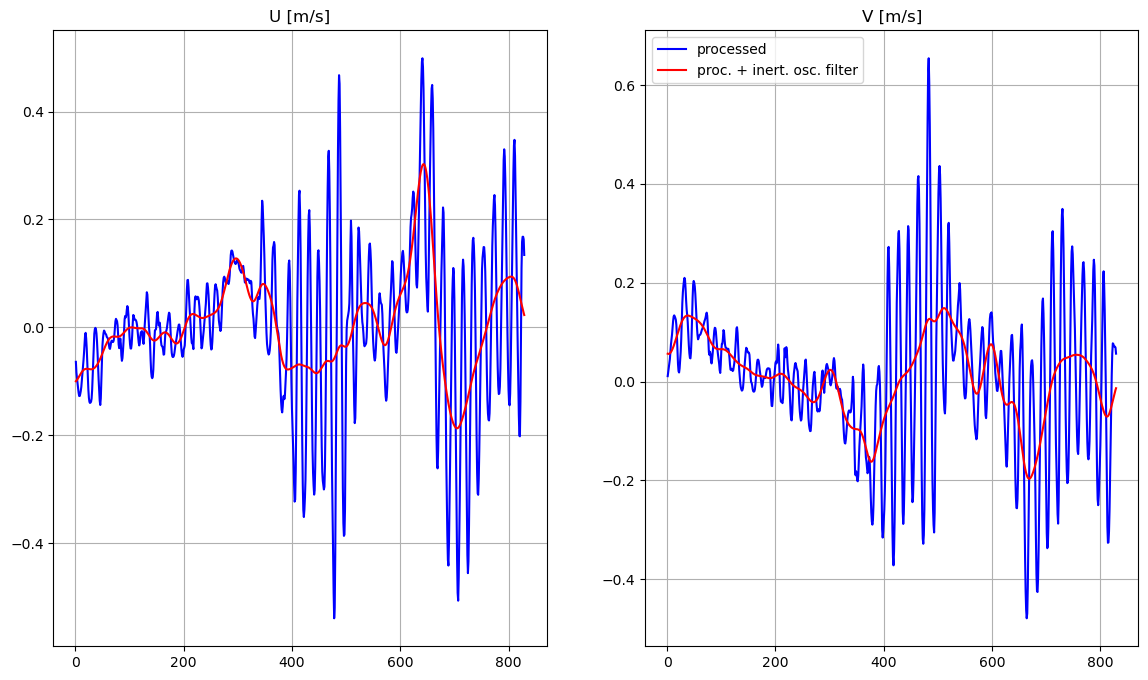

In [29]:
plt.figure(figsize=(14,8))
plt.subplot(1,2,1)
plt.plot(ds.U, c='b')
plt.plot(u, c='r')
plt.title('U [m/s]')
plt.grid()

plt.subplot(1,2,2)
plt.plot(ds.V, c='b', label='processed')
plt.plot(v, c='r', label='proc. + inert. osc. filter')
plt.grid()
plt.title('V [m/s]')
plt.legend(loc=0)
plt.show()

In [30]:
ds_f

<xarray.Dataset>
Dimensions:  (time: 831)
Coordinates:
  * time     (time) datetime64[ns] 2023-04-26T10:00:00 ... 2023-05-31
Data variables:
    LAT      (time) float64 39.64 39.64 39.64 39.65 ... 39.87 39.87 39.87 39.87
    LON      (time) float64 1.422 1.418 1.414 1.41 ... 1.579 1.58 1.581 1.582
    sst      (time) float64 ...
    slp      (time) float64 ...
    U        (time) float64 nan -0.06372 -0.08372 -0.09435 ... 0.1631 0.1343 nan
    V        (time) float64 nan 0.01089 0.01913 0.02703 ... 0.06857 0.05643 nan
Attributes: (12/69)
    title:                               Data from instrument SCB-SVPB038 on ...
    institution:                         SOCIB (Sistema de Observación y pred...
    netcdf_version:                      3.0
    Conventions:                         CF-1.6
    abstract:                            Deployment of surface drifter SCB-SV...
    summary:                             Deployment of surface drifter SCB-SV...
    ...                                  ...
    citation:                            Balearic Island Coastal and Observin...
    acknowledgement:                     National Oceanic and Atmospheric Adm...
    update_interval:                     every 7200 seconds
    DODS.strlen:                         30
    DODS.dimName:                        name_strlen
    DODS_EXTRA.Unlimited_Dimension:      time

In [31]:
outdir_an = "/Users/Gomez023/Library/CloudStorage/OneDrive-UniversitatdelesIllesBalears/FaSt-SWOT/Data/in_situ/analyses/drifters/"


In [32]:
outname

'drifter-svpb038'

In [33]:
ds_f.to_netcdf(outdir_an + outname + 'inertial_osc_filt' + '.nc')